# Bayes-FedPA PeerJ Experiment Notebook — ResNet18 — MNIST

This is a dataset-specific Colab notebook generated from the original lean PeerJ notebook.

## Fixed experiment design

- Dataset: **MNIST**
- Backbone: **ResNet18** adapted for 28×28 images
- Methods: **FedAvg, FedProx, qFedAvg-style, FedPA, Bayes-FedPA**
- Rounds: **10**
- Local epochs: **2**
- Client counts: **5 and 10**
- Seeds: **42 and 123**
- Non-IID Dirichlet alpha values: **0.1, 0.3, 0.5**
- Runs in this notebook: **60**
- Expected round-level rows: **600**
- Dynamic threshold schedule: **0.70 for rounds 1–2, 0.80 for rounds 3–5, 0.85 for rounds 6–10**

The split design is suitable for Colab/T4 and local GTX 1650M 4GB because each dataset can be run separately and resumed if the session disconnects.


In [ ]:

# Install dependencies in Colab
!pip -q install medmnist scikit-learn scipy tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.1 MB/s eta 0:00:00


In [ ]:

import copy, math, random, time, os, json, warnings, gc
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

from torchvision import datasets, transforms
from torchvision.models import resnet18

from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, recall_score
from scipy.special import betainc
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


# Optional: save outputs in Google Drive for long Colab runs.
# Set USE_GOOGLE_DRIVE = True, then run this cell again after accepting the mount prompt.
USE_GOOGLE_DRIVE = False
if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUTPUT_DIR = Path('/content/drive/MyDrive/BayesFedPA_ResNet18_PeerJ_MNIST_outputs')
else:
    OUTPUT_DIR = Path('./bayes_fedpa_resnet18_peerj_MNIST_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Output directory:', OUTPUT_DIR)



def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(42)


Device: cuda
Output directory: bayes_fedpa_resnet18_peerj_MNIST_outputs


## 1. Lean PeerJ Experimental Configuration

This reduced setup is designed to finish in Colab GPU sessions. It keeps the key baselines needed for the paper while removing the very large full matrix.

The extra baseline selected here is **q-FedAvg-style aggregation**, because the proposed method includes fairness-aware exploration. This makes q-FedAvg-style a useful fairness-related comparator.


In [ ]:

# ==============================
# Dataset-specific PeerJ experiment profile
# ==============================
# This notebook runs only one dataset to avoid Colab timeout and GPU memory issues.
RUN_PROFILE = "dataset_peerj"
TARGET_DATASET = "MNIST"

# One dataset per notebook
FULL_DATASETS = [TARGET_DATASET]

# Core comparison:
# FedAvg = standard baseline
# FedProx = heterogeneity-aware baseline
# qFedAvg-style = fairness-oriented comparator
# FedPA = deterministic performance-aware baseline
# Bayes-FedPA = proposed probabilistic method
FULL_METHODS_CORE = ["fedavg", "fedprox", "qfedavg", "fedpa", "bayes_fedpa"]

# Two seeds for practical statistical reporting
FULL_SEEDS = [42, 123]

# Three important non-IID levels: strong, medium, and moderate label skew
FULL_ALPHAS = [0.1, 0.3, 0.5]

# Reduced client scalability setting
FULL_CLIENT_COUNTS = [5, 10]

# Practical GPU setting for Colab/T4 and MSI GTX 1650M 4GB
FULL_ROUNDS = 10
CLIENT_FRACTION = 0.5
LOCAL_EPOCHS = 2
BATCH_SIZE = 256

MODEL_NAME = "resnet18"
PARTITION_TYPE = "dirichlet"
LR = 1e-3
WEIGHT_DECAY = 1e-4
OPTIMIZER_NAME = "adam"

# Bayes-FedPA / FedPA selection settings
TAU = 0.85
RHO = 0.70
WARMUP_ROUNDS = 2
USE_DYNAMIC_TAU = True
DYNAMIC_TAU_VALUES = (0.70, 0.80, 0.85)

# Corrected schedule for 10 rounds:
# rounds 1-2 -> 0.70, rounds 3-5 -> 0.80, rounds 6-10 -> 0.85
DYNAMIC_TAU_STEPS = (2, 5)

EXPLORATION_RATIO = 0.10
FAIRNESS_EPS = 0.05
FALLBACK_TOP_K = 2

# FedProx and q-FedAvg-style settings
FEDPROX_MU = 0.01
QFEDAVG_Q = 0.5

# Server optimizer settings kept only for compatibility with existing functions
SERVER_LR = 1.0
SERVER_BETA1 = 0.9
SERVER_BETA2 = 0.99
SERVER_TAU = 1e-3

# Communication accounting
SCALAR_STATS_PER_CLIENT = 6  # correct, total, n, accuracy, macro-f1, val-loss
SCALAR_BYTES = 8

# Run control
RUN_CORE_COMPARISON = True
RUN_BAYES_ABLATIONS = False
RESUME_COMPLETED_RUNS = True

# For safer long Colab sessions, set this to 5, 10, or 20.
# Leave as None to run all unfinished runs for this dataset.
MAX_RUNS_PER_SESSION = None

# Client-level fairness evaluation is costly. Every 10 rounds plus final round is enough.
EVAL_CLIENT_FAIRNESS_EVERY = 10

# Ablations are disabled to keep exactly 60 runs per dataset.
BAYES_ABLATION_CONFIGS = []

print("Dataset-specific PeerJ profile")
print("Target dataset:", TARGET_DATASET)
print("Datasets:", FULL_DATASETS)
print("Methods:", FULL_METHODS_CORE)
print("Seeds:", FULL_SEEDS)
print("Dirichlet alphas:", FULL_ALPHAS)
print("Client counts:", FULL_CLIENT_COUNTS)
print("Rounds:", FULL_ROUNDS)
print("Local epochs:", LOCAL_EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Dynamic tau values:", DYNAMIC_TAU_VALUES)
print("Dynamic tau steps:", DYNAMIC_TAU_STEPS)
core_runs = len(FULL_DATASETS) * len(FULL_METHODS_CORE) * len(FULL_SEEDS) * len(FULL_ALPHAS) * len(FULL_CLIENT_COUNTS)
print("Total core runs in this notebook:", core_runs)
print("Expected round-level rows:", core_runs * FULL_ROUNDS)


Dataset-specific PeerJ profile
Target dataset: MNIST
Datasets: ['MNIST']
Methods: ['fedavg', 'fedprox', 'qfedavg', 'fedpa', 'bayes_fedpa']
Seeds: [42, 123]
Dirichlet alphas: [0.1, 0.3, 0.5]
Client counts: [5, 10]
Rounds: 10
Local epochs: 2
Batch size: 256
Dynamic tau values: (0.7, 0.8, 0.85)
Dynamic tau steps: (2, 5)
Total core runs in this notebook: 60
Expected round-level rows: 600



## 2. Dataset Loading and Non-IID Partitioning


In [ ]:

def get_dataset(dataset_name, root="./data"):
    dataset_name = dataset_name.upper()

    if dataset_name == "MNIST":
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])
        train_dataset = datasets.MNIST(root=root, train=True, download=True, transform=transform)
        test_dataset = datasets.MNIST(root=root, train=False, download=True, transform=transform)
        return train_dataset, test_dataset, 1, 10

    if dataset_name in ["ORGANAMNIST", "OCTMNIST"]:
        import medmnist
        from medmnist import INFO

        med_name = dataset_name.lower()
        info = INFO[med_name]
        DataClass = getattr(medmnist, info["python_class"])
        n_channels = int(info["n_channels"])
        n_classes = len(info["label"])

        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5] * n_channels, std=[0.5] * n_channels)
        ])

        train_dataset = DataClass(split="train", transform=transform, download=True, root=root)
        val_dataset = DataClass(split="val", transform=transform, download=True, root=root)
        test_dataset = DataClass(split="test", transform=transform, download=True, root=root)

        # Combine official train + validation for client-side train/val splitting.
        # The official test split remains untouched for global evaluation.
        from torch.utils.data import ConcatDataset
        trainval_dataset = ConcatDataset([train_dataset, val_dataset])
        return trainval_dataset, test_dataset, n_channels, n_classes

    raise ValueError(f"Unsupported dataset: {dataset_name}")


def get_targets(dataset):
    # Return integer labels for torchvision, MedMNIST, Subset, or ConcatDataset.
    if isinstance(dataset, Subset):
        parent_targets = np.array(get_targets(dataset.dataset))
        return parent_targets[np.array(dataset.indices)]

    if hasattr(dataset, "datasets"):  # ConcatDataset
        parts = [np.array(get_targets(d)).reshape(-1) for d in dataset.datasets]
        return np.concatenate(parts, axis=0).astype(int)

    if hasattr(dataset, "targets"):
        return np.array(dataset.targets).reshape(-1).astype(int)

    if hasattr(dataset, "labels"):
        return np.array(dataset.labels).reshape(-1).astype(int)

    raise ValueError("Could not extract labels from dataset")


def iid_partition(labels, num_clients, seed=42):
    rng = np.random.default_rng(seed)
    indices = np.arange(len(labels))
    rng.shuffle(indices)
    return [split.tolist() for split in np.array_split(indices, num_clients)]


def dirichlet_partition(labels, num_clients, alpha=0.5, min_size=10, seed=42, max_tries=200):
    rng = np.random.default_rng(seed)
    labels = np.array(labels).reshape(-1).astype(int)
    num_classes = int(labels.max()) + 1

    for _ in range(max_tries):
        client_indices = [[] for _ in range(num_clients)]
        for c in range(num_classes):
            class_indices = np.where(labels == c)[0]
            rng.shuffle(class_indices)
            proportions = rng.dirichlet([alpha] * num_clients)
            split_points = (np.cumsum(proportions) * len(class_indices)).astype(int)[:-1]
            class_splits = np.split(class_indices, split_points)
            for client_id, split in enumerate(class_splits):
                client_indices[client_id].extend(split.tolist())

        sizes = [len(x) for x in client_indices]
        if min(sizes) >= min_size:
            for x in client_indices:
                rng.shuffle(x)
            return client_indices

    raise RuntimeError(f"Dirichlet partition failed after {max_tries} attempts. Try larger alpha or smaller min_size.")


def split_train_val(indices, val_fraction=0.20, seed=42):
    rng = np.random.default_rng(seed)
    indices = np.array(indices)
    rng.shuffle(indices)
    val_size = max(1, int(len(indices) * val_fraction))
    val_indices = indices[:val_size].tolist()
    train_indices = indices[val_size:].tolist()
    if len(train_indices) == 0:
        train_indices = val_indices
    return train_indices, val_indices


def build_client_loaders(dataset, labels, num_clients=10, partition_type="dirichlet", alpha=0.5,
                         batch_size=128, val_fraction=0.20, seed=42, min_size=20, num_workers=2):
    if partition_type == "iid":
        partitions = iid_partition(labels, num_clients=num_clients, seed=seed)
    elif partition_type == "dirichlet":
        partitions = dirichlet_partition(labels, num_clients=num_clients, alpha=alpha, min_size=min_size, seed=seed)
    else:
        raise ValueError("partition_type must be 'iid' or 'dirichlet'")

    client_train_loaders, client_val_loaders = [], []
    client_train_sizes, client_val_sizes = [], []

    for cid, indices in enumerate(partitions):
        train_idx, val_idx = split_train_val(indices, val_fraction=val_fraction, seed=seed + cid)
        train_loader = DataLoader(Subset(dataset, train_idx), batch_size=batch_size, shuffle=True,
                                  num_workers=num_workers, pin_memory=torch.cuda.is_available())
        val_loader = DataLoader(Subset(dataset, val_idx), batch_size=batch_size, shuffle=False,
                                num_workers=num_workers, pin_memory=torch.cuda.is_available())
        client_train_loaders.append(train_loader)
        client_val_loaders.append(val_loader)
        client_train_sizes.append(len(train_idx))
        client_val_sizes.append(len(val_idx))

    return client_train_loaders, client_val_loaders, partitions, client_train_sizes, client_val_sizes



## 3. ResNet18 Backbone for Small 28×28 Images

This uses the standard ResNet18 block structure but adapts the first convolution and removes the initial max-pooling layer for 28×28 images. This keeps the experiment as **ResNet18-based** while making it suitable for MNIST and MedMNIST small images.


In [ ]:

def create_resnet18_small_image(in_channels=1, num_classes=10):
    model = resnet18(weights=None)
    model.conv1 = nn.Conv2d(in_channels, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def create_model(model_name="resnet18", in_channels=1, num_classes=10):
    model_name = model_name.lower()
    if model_name != "resnet18":
        raise ValueError("This revised notebook intentionally supports only ResNet18 for all experiments.")
    return create_resnet18_small_image(in_channels=in_channels, num_classes=num_classes)


def count_state_dict_bytes(model):
    return sum(t.numel() * t.element_size() for t in model.state_dict().values() if torch.is_tensor(t))


def model_parameter_count(model):
    return sum(p.numel() for p in model.parameters())



## 4. Training, Evaluation, Aggregation, and Server Optimizers


In [ ]:
def move_batch_to_device(batch):
    x, y = batch
    x = x.to(DEVICE, non_blocking=True)
    y = y.view(-1).long().to(DEVICE, non_blocking=True)
    return x, y


def evaluate_model(model, data_loader, num_classes):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    all_preds, all_targets = [], []
    total_loss, total_samples, correct = 0.0, 0, 0

    with torch.no_grad():
        for batch in data_loader:
            x, y = move_batch_to_device(batch)
            logits = model(x)
            loss = criterion(logits, y)
            preds = torch.argmax(logits, dim=1)

            total_loss += loss.item() * y.size(0)
            total_samples += y.size(0)
            correct += (preds == y).sum().item()
            all_preds.extend(preds.detach().cpu().numpy())
            all_targets.extend(y.detach().cpu().numpy())

    if total_samples == 0:
        base = {"loss": np.nan, "accuracy": 0.0, "macro_f1": 0.0, "weighted_f1": 0.0,
                "balanced_accuracy": 0.0, "correct": 0, "total": 0,
                "worst_class_recall": 0.0, "worst_class_f1": 0.0}
        return base

    labels = list(range(num_classes))
    recalls = recall_score(all_targets, all_preds, labels=labels, average=None, zero_division=0)
    f1s = f1_score(all_targets, all_preds, labels=labels, average=None, zero_division=0)

    metrics = {
        "loss": total_loss / total_samples,
        "accuracy": correct / total_samples,
        "macro_f1": f1_score(all_targets, all_preds, average="macro", zero_division=0),
        "weighted_f1": f1_score(all_targets, all_preds, average="weighted", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(all_targets, all_preds),
        "correct": int(correct),
        "total": int(total_samples),
        "worst_class_recall": float(np.min(recalls)),
        "worst_class_f1": float(np.min(f1s)),
    }
    for c in range(num_classes):
        metrics[f"class_{c}_recall"] = float(recalls[c])
        metrics[f"class_{c}_f1"] = float(f1s[c])
    return metrics


def train_one_client(model, train_loader, global_state=None, local_epochs=1, lr=1e-3, weight_decay=1e-4,
                     optimizer_name="adam", method="fedavg", fedprox_mu=0.01):
    model.train()
    criterion = nn.CrossEntropyLoss()
    if optimizer_name.lower() == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    global_tensors = None
    if method == "fedprox" and global_state is not None:
        global_tensors = {k: v.detach().clone().to(DEVICE) for k, v in global_state.items() if torch.is_floating_point(v)}

    total_loss, total_samples = 0.0, 0
    for _ in range(local_epochs):
        for batch in train_loader:
            x, y = move_batch_to_device(batch)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)

            if method == "fedprox" and global_tensors is not None:
                prox = torch.tensor(0.0, device=DEVICE)
                for name, param in model.named_parameters():
                    if name in global_tensors:
                        prox = prox + torch.sum((param - global_tensors[name]) ** 2)
                loss = loss + 0.5 * fedprox_mu * prox

            loss.backward()
            optimizer.step()
            total_loss += loss.item() * y.size(0)
            total_samples += y.size(0)

    return total_loss / max(total_samples, 1)


def normalize_weights(values):
    values = np.array(values, dtype=np.float64)
    if len(values) == 0:
        return values
    values = np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0)
    values = np.maximum(values, 0.0)
    total = values.sum()
    if total <= 0:
        return np.ones_like(values) / len(values)
    return values / total


def aggregate_state_dicts(state_dicts, weights):
    if len(state_dicts) == 0:
        raise ValueError("No client models for aggregation")
    weights = normalize_weights(weights)
    aggregated = copy.deepcopy(state_dicts[0])

    for key in aggregated.keys():
        if torch.is_floating_point(aggregated[key]):
            out = torch.zeros_like(aggregated[key], dtype=torch.float32)
            for state, weight in zip(state_dicts, weights):
                out += state[key].float() * float(weight)
            aggregated[key] = out
        else:
            aggregated[key] = state_dicts[0][key].clone()
    return aggregated


def init_server_optimizer_state(global_state):
    m, v = {}, {}
    for k, t in global_state.items():
        if torch.is_floating_point(t):
            m[k] = torch.zeros_like(t, dtype=torch.float32)
            v[k] = torch.zeros_like(t, dtype=torch.float32)
    return {"m": m, "v": v, "t": 0}


def server_adaptive_update(global_state, aggregated_state, opt_state, optimizer="fedadam",
                           server_lr=1.0, beta1=0.9, beta2=0.99, tau=1e-3):
    # Apply FedAdam/FedYogi-style server update using delta = aggregated_state - global_state.
    optimizer = optimizer.lower()
    if opt_state is None:
        opt_state = init_server_optimizer_state(global_state)
    opt_state["t"] += 1

    new_state = copy.deepcopy(global_state)
    for k in global_state.keys():
        if not torch.is_floating_point(global_state[k]):
            new_state[k] = global_state[k].clone()
            continue

        # Move aggregated_state[k] to the same device as global_state[k] before subtraction
        g = aggregated_state[k].to(DEVICE).float() - global_state[k].float()
        opt_state["m"][k] = beta1 * opt_state["m"][k] + (1 - beta1) * g

        if optimizer == "fedyogi":
            opt_state["v"][k] = opt_state["v"][k] - (1 - beta2) * (g ** 2) * torch.sign(opt_state["v"][k] - g ** 2)
        else:  # FedAdam
            opt_state["v"][k] = beta2 * opt_state["v"][k] + (1 - beta2) * (g ** 2)

        new_state[k] = global_state[k].float() + server_lr * opt_state["m"][k] / (torch.sqrt(opt_state["v"][k]) + tau)
    return new_state, opt_state


def compute_bayes_statistics(correct, total, tau, alpha0=1.0, beta0=1.0):
    total = max(int(total), 1)
    correct = int(correct)
    a = alpha0 + correct
    b = beta0 + total - correct
    mu = a / (a + b)
    var = (a * b) / (((a + b) ** 2) * (a + b + 1))
    posterior_conf = 1.0 - float(betainc(a, b, tau))
    return {"a": a, "b": b, "mu": mu, "var": var, "posterior_conf": posterior_conf}


def jain_index(values):
    values = np.array(values, dtype=np.float64)
    if len(values) == 0:
        return 0.0
    values = np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0)
    values = np.maximum(values, 0.0)
    total = values.sum()
    if total <= 0:
        return 0.0
    denom = len(values) * np.sum(values ** 2) # The original line was missing this definition.
    if denom <= 0: # Adding check for denom to avoid ZeroDivisionError
        return 0.0
    return float((np.sum(values) ** 2) / denom)


def current_tau(round_idx, tau=0.85, use_dynamic_tau=True, tau_values=(0.70, 0.80, 0.85), tau_steps=(2, 5)):
    if not use_dynamic_tau:
        return tau
    tau_min, tau_mid, tau_max = tau_values
    t1, t2 = tau_steps
    if round_idx < t1:
        return tau_min
    if round_idx < t2:
        return tau_mid
    return tau_max


## 5. Federated Experiment Runner


In [ ]:

def evaluate_client_fairness(global_model, client_val_loaders, num_classes):
    accs = []
    for loader in client_val_loaders:
        m = evaluate_model(global_model, loader, num_classes)
        accs.append(m["accuracy"])
    return {
        "worst_client_val_acc": float(np.min(accs)) if accs else 0.0,
        "mean_client_val_acc": float(np.mean(accs)) if accs else 0.0,
        "std_client_val_acc": float(np.std(accs)) if accs else 0.0,
    }


def select_and_weight_clients(method, active_clients, client_stats, train_sizes, round_idx,
                              participation_counts, num_clients, cfg):
    # Return final selected clients, aggregation weights, and selection diagnostics.
    method = method.lower()
    tau_t = current_tau(round_idx, cfg["tau"], cfg["use_dynamic_tau"], cfg["dynamic_tau_values"], cfg["dynamic_tau_steps"])
    warmup = round_idx < cfg["warmup_rounds"]

    if method in ["fedavg", "fedprox", "fedadam", "fedyogi"] or warmup:
        selected = list(active_clients)
        weights = [train_sizes[cid] for cid in selected]
        return selected, normalize_weights(weights), {
            "tau_t": tau_t,
            "threshold_selected_clients": len(selected),
            "exploration_added_clients": 0,
            "fallback_used": False,
            "selection_reason": "all_active" if not warmup else "warmup_all_active",
        }

    if method == "qfedavg":
        # Practical q-FedAvg-style fairness baseline: clients with larger validation loss receive more weight.
        # This is not a full q-FFL optimizer; it is a loss-powered aggregation baseline for comparative analysis.
        selected = list(active_clients)
        weights = [(train_sizes[cid] * ((client_stats[cid]["loss"] + cfg["eps"]) ** cfg["qfedavg_q"])) for cid in selected]
        return selected, normalize_weights(weights), {
            "tau_t": tau_t,
            "threshold_selected_clients": len(selected),
            "exploration_added_clients": 0,
            "fallback_used": False,
            "selection_reason": "qfedavg_loss_weighted",
        }

    if method == "fedpa":
        reliability = {}
        for cid in active_clients:
            reliability[cid] = 0.5 * client_stats[cid]["accuracy"] + 0.5 * client_stats[cid]["macro_f1"]
        threshold_selected = [cid for cid in active_clients if reliability[cid] >= tau_t]
        fallback_used = False
        if len(threshold_selected) == 0:
            threshold_selected = sorted(active_clients, key=lambda c: reliability[c], reverse=True)[:cfg["fallback_top_k"]]
            fallback_used = True
        weights = [max(reliability[cid], cfg["eps"]) for cid in threshold_selected]
        return threshold_selected, normalize_weights(weights), {
            "tau_t": tau_t,
            "threshold_selected_clients": len(threshold_selected),
            "exploration_added_clients": 0,
            "fallback_used": fallback_used,
            "selection_reason": "deterministic_threshold",
        }

    if method == "bayes_fedpa":
        bayes = {}
        for cid in active_clients:
            bayes[cid] = compute_bayes_statistics(
                correct=client_stats[cid]["correct"],
                total=client_stats[cid]["total"],
                tau=tau_t,
                alpha0=cfg["alpha0"],
                beta0=cfg["beta0"],
            )

        threshold_selected = [cid for cid in active_clients if bayes[cid]["posterior_conf"] >= cfg["rho"]]
        fallback_used = False
        if len(threshold_selected) == 0:
            threshold_selected = sorted(active_clients, key=lambda c: bayes[c]["posterior_conf"], reverse=True)[:cfg["fallback_top_k"]]
            fallback_used = True

        selected_set = set(threshold_selected)
        exploration_added = []
        if cfg["use_fairness_exploration"] and cfg["exploration_ratio"] > 0:
            budget = int(math.ceil(cfg["exploration_ratio"] * len(active_clients)))
            candidates = [cid for cid in active_clients if cid not in selected_set]
            candidates = sorted(candidates, key=lambda c: 1.0 / (1.0 + participation_counts[c]), reverse=True)
            exploration_added = candidates[:budget]
            selected_set.update(exploration_added)

        selected = sorted(list(selected_set))

        scores = []
        for cid in selected:
            b = bayes.get(cid)
            if b is None:
                b = compute_bayes_statistics(client_stats[cid]["correct"], client_stats[cid]["total"], tau_t,
                                             cfg["alpha0"], cfg["beta0"])
            var_term = (b["var"] + cfg["eps"]) if cfg["use_variance_penalty"] else 1.0
            score = ((train_sizes[cid] ** cfg["weight_n"]) *
                     ((b["mu"] + cfg["eps"]) ** cfg["weight_mu"]) *
                     ((b["posterior_conf"] + cfg["eps"]) ** cfg["weight_p"]) /
                     (var_term ** cfg["weight_var"]))
            scores.append(score)

        weights = normalize_weights(scores)
        if cfg["fairness_eps"] > 0:
            weights = (1.0 - cfg["fairness_eps"]) * weights + cfg["fairness_eps"] / len(weights)
            weights = normalize_weights(weights)

        return selected, weights, {
            "tau_t": tau_t,
            "threshold_selected_clients": len(threshold_selected),
            "exploration_added_clients": len(exploration_added),
            "fallback_used": fallback_used,
            "selection_reason": "posterior_confidence",
            "posterior_conf_mean": float(np.mean([bayes[c]["posterior_conf"] for c in active_clients])),
            "posterior_var_mean": float(np.mean([bayes[c]["var"] for c in active_clients])),
        }

    raise ValueError(f"Unknown method: {method}")


def run_federated_experiment(
    dataset_name="MNIST",
    method="bayes_fedpa",
    variant="main",
    model_name="resnet18",
    num_clients=10,
    partition_type="dirichlet",
    alpha=0.5,
    client_fraction=0.5,
    rounds=50,
    local_epochs=2,
    batch_size=128,
    lr=1e-3,
    weight_decay=1e-4,
    optimizer_name="adam",
    seed=42,
    fedprox_mu=0.01,
    tau=0.85,
    rho=0.70,
    alpha0=1.0,
    beta0=1.0,
    warmup_rounds=2,
    use_dynamic_tau=True,
    dynamic_tau_values=(0.70, 0.80, 0.85),
    dynamic_tau_steps=(2, 5),
    exploration_ratio=0.10,
    fairness_eps=0.05,
    fallback_top_k=2,
    use_fairness_exploration=True,
    use_variance_penalty=True,
    weight_n=1.0,
    weight_mu=1.0,
    weight_p=1.0,
    weight_var=1.0,
    server_lr=1.0,
    server_beta1=0.9,
    server_beta2=0.99,
    server_tau=1e-3,
    qfedavg_q=0.5,
    root="./data",
    eval_client_fairness_every=5,
    verbose=True,
):
    set_seed(seed)
    method = method.lower()
    start_time = time.time()

    train_dataset, test_dataset, in_channels, num_classes = get_dataset(dataset_name, root=root)
    labels = get_targets(train_dataset)

    client_train_loaders, client_val_loaders, partitions, train_sizes, val_sizes = build_client_loaders(
        train_dataset, labels, num_clients=num_clients, partition_type=partition_type, alpha=alpha,
        batch_size=batch_size, val_fraction=0.20, seed=seed, min_size=max(10, batch_size // 8)
    )
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2,
                             pin_memory=torch.cuda.is_available())

    global_model = create_model(model_name, in_channels=in_channels, num_classes=num_classes).to(DEVICE)
    global_state = copy.deepcopy(global_model.state_dict())
    model_bytes = count_state_dict_bytes(global_model)
    model_params = model_parameter_count(global_model)
    scalar_stats_bytes = SCALAR_STATS_PER_CLIENT * SCALAR_BYTES

    server_opt_state = None
    participation_counts = np.zeros(num_clients, dtype=np.int64)
    total_full_uploads = 0
    logs = []

    cfg = {
        "tau": tau, "rho": rho, "alpha0": alpha0, "beta0": beta0,
        "warmup_rounds": warmup_rounds, "use_dynamic_tau": use_dynamic_tau,
        "dynamic_tau_values": dynamic_tau_values, "dynamic_tau_steps": dynamic_tau_steps,
        "exploration_ratio": exploration_ratio, "fairness_eps": fairness_eps,
        "fallback_top_k": fallback_top_k, "use_fairness_exploration": use_fairness_exploration,
        "use_variance_penalty": use_variance_penalty,
        "weight_n": weight_n, "weight_mu": weight_mu, "weight_p": weight_p, "weight_var": weight_var,
        "eps": 1e-8, "qfedavg_q": qfedavg_q,
    }

    rng = np.random.default_rng(seed)
    active_count = max(1, int(math.ceil(client_fraction * num_clients)))

    iterator = range(rounds)
    if verbose:
        iterator = tqdm(iterator, desc=f"{dataset_name}-{method}-{variant}-seed{seed}-alpha{alpha}")

    for round_idx in iterator:
        round_start = time.time()
        active_clients = sorted(rng.choice(num_clients, size=active_count, replace=False).tolist())

        client_states = {}
        client_stats = {}
        client_train_losses = {}

        # All active clients train locally and first send lightweight reliability statistics.
        for cid in active_clients:
            local_model = create_model(model_name, in_channels=in_channels, num_classes=num_classes).to(DEVICE)
            local_model.load_state_dict(global_state)
            local_loss = train_one_client(
                local_model, client_train_loaders[cid], global_state=global_state,
                local_epochs=local_epochs, lr=lr, weight_decay=weight_decay, optimizer_name=optimizer_name,
                method=("fedprox" if method == "fedprox" else "fedavg"), fedprox_mu=fedprox_mu
            )
            val_metrics = evaluate_model(local_model, client_val_loaders[cid], num_classes)
            client_states[cid] = copy.deepcopy({k: v.detach().cpu() for k, v in local_model.state_dict().items()})
            client_stats[cid] = val_metrics
            client_train_losses[cid] = local_loss
            del local_model
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        selected_clients, agg_weights, select_info = select_and_weight_clients(
            method, active_clients, client_stats, train_sizes, round_idx,
            participation_counts, num_clients, cfg
        )

        selected_states = [client_states[cid] for cid in selected_clients]
        aggregated_state = aggregate_state_dicts(selected_states, agg_weights)

        if method in ["fedadam", "fedyogi"]:
            global_state, server_opt_state = server_adaptive_update(
                global_state, aggregated_state, server_opt_state, optimizer=method,
                server_lr=server_lr, beta1=server_beta1, beta2=server_beta2, tau=server_tau
            )
        else:
            global_state = aggregated_state

        global_model.load_state_dict(global_state)
        participation_counts[selected_clients] += 1
        total_full_uploads += len(selected_clients)

        test_metrics = evaluate_model(global_model, test_loader, num_classes)

        fairness_eval = {"worst_client_val_acc": np.nan, "mean_client_val_acc": np.nan, "std_client_val_acc": np.nan}
        if (round_idx == rounds - 1) or ((round_idx + 1) % eval_client_fairness_every == 0):
            fairness_eval = evaluate_client_fairness(global_model, client_val_loaders, num_classes)

        # Communication accounting: two-stage for FedPA/Bayes-FedPA/q-like methods, full uploads for full aggregation methods.
        scalar_uplink_bytes = len(active_clients) * scalar_stats_bytes
        full_upload_bytes = len(selected_clients) * model_bytes
        uplink_mb = (scalar_uplink_bytes + full_upload_bytes) / (1024 ** 2)
        fedavg_equiv_mb = (len(active_clients) * model_bytes) / (1024 ** 2)
        comm_saving_vs_fedavg = 1.0 - (uplink_mb / max(fedavg_equiv_mb, 1e-12))

        row = {
            "dataset": dataset_name,
            "method": method,
            "variant": variant,
            "model_name": model_name,
            "seed": seed,
            "alpha": alpha,
            "num_clients": num_clients,
            "client_fraction": client_fraction,
            "round": round_idx + 1,
            "local_epochs": local_epochs,
            "batch_size": batch_size,
            "lr": lr,
            "weight_decay": weight_decay,
            "active_clients": len(active_clients),
            "selected_clients": len(selected_clients),
            "selected_client_ids": json.dumps(selected_clients),
            "selected_weights": json.dumps([float(x) for x in agg_weights]),
            "total_full_uploads_so_far": total_full_uploads,
            "model_params": model_params,
            "model_update_mb": model_bytes / (1024 ** 2),
            "uplink_mb_round": uplink_mb,
            "fedavg_equiv_uplink_mb_round": fedavg_equiv_mb,
            "comm_saving_vs_fedavg_round": comm_saving_vs_fedavg,
            "jain_participation": jain_index(participation_counts),
            "round_time_sec": time.time() - round_start,
            "elapsed_time_sec": time.time() - start_time,
            **select_info,
            **test_metrics,
            **fairness_eval,
        }
        logs.append(row)

        if verbose:
            iterator.set_postfix({
                "acc": f"{row['accuracy']:.3f}",
                "f1": f"{row['macro_f1']:.3f}",
                "sel": row["selected_clients"],
                "J": f"{row['jain_participation']:.2f}",
            })

    return pd.DataFrame(logs)


## 6. Lean Master Runner with Resume Support

This runner saves every completed experiment as a separate CSV file. If Colab disconnects, rerun the notebook. Completed runs will be skipped automatically.

The notebook also provides separate run cells for MNIST, OrganAMNIST, and OCTMNIST.


In [ ]:
import json # Ensure json is imported
from pathlib import Path # Ensure Path is imported
import pandas as pd # Ensure pandas is imported as it is used in the functions

# Re-define OUTPUT_DIR only if the setup cell was not run.
# Default is local output because Google Drive was unreliable in previous runs.
if 'USE_GOOGLE_DRIVE' not in globals():
    USE_GOOGLE_DRIVE = False

if 'OUTPUT_DIR' not in globals():
    if USE_GOOGLE_DRIVE:
        OUTPUT_DIR = Path('/content/drive/MyDrive/BayesFedPA_ResNet18_PeerJ_MNIST_outputs')
    else:
        OUTPUT_DIR = Path('./bayes_fedpa_resnet18_peerj_MNIST_outputs')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Ensure these are defined for the functions within this cell
# These variables would typically come from an earlier configuration cell (vmczB1AB4TPM).
# Adding minimal definitions here to allow the helper functions to run if those cells haven't been executed.
# In a complete run, these would be overwritten by values from vmczB1AB4TPM.
if 'FULL_ROUNDS' not in globals():
    FULL_ROUNDS = 10 # Default value, should be loaded from config cell
if 'MODEL_NAME' not in globals():
    MODEL_NAME = "resnet18" # Default value, should be loaded from config cell
if 'RESUME_COMPLETED_RUNS' not in globals():
    RESUME_COMPLETED_RUNS = True # Default value, should be loaded from config cell
if 'PARTITION_TYPE' not in globals():
    PARTITION_TYPE = "dirichlet" # Default value, should be loaded from config cell
if 'CLIENT_FRACTION' not in globals():
    CLIENT_FRACTION = 0.5 # Default value, should be loaded from config cell
if 'LOCAL_EPOCHS' not in globals():
    LOCAL_EPOCHS = 2 # Default value, should be loaded from config cell
if 'BATCH_SIZE' not in globals():
    BATCH_SIZE = 256 # Default value, should be loaded from config cell
if 'LR' not in globals():
    LR = 1e-3 # Default value, should be loaded from config cell
if 'WEIGHT_DECAY' not in globals():
    WEIGHT_DECAY = 1e-4 # Default value, should be loaded from config cell
if 'OPTIMIZER_NAME' not in globals():
    OPTIMIZER_NAME = "adam" # Default value, should be loaded from config cell
if 'FEDPROX_MU' not in globals():
    FEDPROX_MU = 0.01 # Default value, should be loaded from config cell
if 'TAU' not in globals():
    TAU = 0.85 # Default value, should be loaded from config cell
if 'RHO' not in globals():
    RHO = 0.70 # Default value, should be loaded from config cell
if 'WARMUP_ROUNDS' not in globals():
    WARMUP_ROUNDS = 2 # Default value, should be loaded from config cell
if 'USE_DYNAMIC_TAU' not in globals():
    USE_DYNAMIC_TAU = True # Default value, should be loaded from config cell
if 'DYNAMIC_TAU_VALUES' not in globals():
    DYNAMIC_TAU_VALUES = (0.70, 0.80, 0.85) # Default value, should be loaded from config cell
if 'DYNAMIC_TAU_STEPS' not in globals():
    DYNAMIC_TAU_STEPS = (2, 5) # Default value, should be loaded from config cell
if 'EXPLORATION_RATIO' not in globals():
    EXPLORATION_RATIO = 0.10 # Default value, should be loaded from config cell
if 'FAIRNESS_EPS' not in globals():
    FAIRNESS_EPS = 0.05 # Default value, should be loaded from config cell
if 'FALLBACK_TOP_K' not in globals():
    FALLBACK_TOP_K = 2 # Default value, should be loaded from config cell
if 'SERVER_LR' not in globals():
    SERVER_LR = 1.0 # Default value, should be loaded from config cell
if 'SERVER_BETA1' not in globals():
    SERVER_BETA1 = 0.9 # Default value, should be loaded from config cell
if 'SERVER_BETA2' not in globals():
    SERVER_BETA2 = 0.99 # Default value, should be loaded from config cell
if 'SERVER_TAU' not in globals():
    SERVER_TAU = 1e-3 # Default value, should be loaded from config cell
if 'QFEDAVG_Q' not in globals():
    QFEDAVG_Q = 0.5 # Default value, should be loaded from config cell
if 'EVAL_CLIENT_FAIRNESS_EVERY' not in globals():
    EVAL_CLIENT_FAIRNESS_EVERY = 10 # Default value, should be loaded from config cell
if 'MAX_RUNS_PER_SESSION' not in globals():
    MAX_RUNS_PER_SESSION = None # Default value, should be loaded from config cell
if 'FULL_DATASETS' not in globals():
    FULL_DATASETS = ["MNIST"] # Default value, should be loaded from config cell
if 'FULL_CLIENT_COUNTS' not in globals():
    FULL_CLIENT_COUNTS = [5, 10] # Default value, should be loaded from config cell
if 'FULL_ALPHAS' not in globals():
    FULL_ALPHAS = [0.1, 0.3, 0.5] # Default value, should be loaded from config cell
if 'FULL_METHODS_CORE' not in globals():
    FULL_METHODS_CORE = ["fedavg", "fedprox", "qfedavg", "fedpa", "bayes_fedpa"] # Default value, should be loaded from config cell
if 'FULL_SEEDS' not in globals():
    FULL_SEEDS = [42, 123] # Default value, should be loaded from config cell
if 'SCALAR_STATS_PER_CLIENT' not in globals():
    SCALAR_STATS_PER_CLIENT = 6 # Default value, should be loaded from config cell
if 'SCALAR_BYTES' not in globals():
    SCALAR_BYTES = 8 # Default value, should be loaded from config cell

def safe_name(x):
    return str(x).replace("/", "-").replace(" ", "_").replace(".", "p")

COMPLETED_FILE = OUTPUT_DIR / "completed_runs.jsonl"
CORE_DIR = OUTPUT_DIR / "core_runs"
ABLATION_DIR = OUTPUT_DIR / "ablation_runs"
CORE_DIR.mkdir(parents=True, exist_ok=True)
ABLATION_DIR.mkdir(parents=True, exist_ok=True)


def run_key(stage, dataset, method, variant, seed, alpha, num_clients, rounds):
    return {
        "stage": stage,
        "dataset": dataset,
        "method": method,
        "variant": variant,
        "seed": int(seed),
        "alpha": float(alpha),
        "num_clients": int(num_clients),
        "rounds": int(rounds),
        "model_name": MODEL_NAME,
    }


def key_to_str(k):
    return json.dumps(k, sort_keys=True)


def load_completed_keys():
    completed = set()
    if COMPLETED_FILE.exists():
        with open(COMPLETED_FILE, "r") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    completed.add(key_to_str(json.loads(line)))
                except Exception:
                    pass
    return completed


def mark_completed(k):
    with open(COMPLETED_FILE, "a") as f:
        f.write(json.dumps(k, sort_keys=True) + "\n")


def output_file_for_key(k):
    folder = CORE_DIR if k["stage"] == "core" else ABLATION_DIR
    fname = (
        f"{safe_name(k['stage'])}__{safe_name(k['dataset'])}__{safe_name(k['method'])}__"
        f"{safe_name(k['variant'])}__K{k['num_clients']}__alpha{safe_name(k['alpha'])}__"
        f"seed{k['seed']}__R{k['rounds']}.csv"
    )
    return folder / fname


def run_single_combo(stage, dataset_name, method, variant, seed, alpha, num_clients, ablation_cfg=None):
    ablation_cfg = ablation_cfg or {}
    k = run_key(stage, dataset_name, method, variant, seed, alpha, num_clients, FULL_ROUNDS)
    out_file = output_file_for_key(k)
    completed_keys = load_completed_keys()

    if RESUME_COMPLETED_RUNS and key_to_str(k) in completed_keys and out_file.exists():
        print(f"SKIP completed: {out_file.name}")
        return pd.read_csv(out_file)

    print("\n" + "=" * 110)
    print(f"RUN: stage={stage} | dataset={dataset_name} | method={method} | variant={variant} | "
          f"K={num_clients} | alpha={alpha} | seed={seed} | rounds={FULL_ROUNDS}")
    print("=" * 110)

    # Assuming run_federated_experiment is defined in an earlier cell or imported
    # For robustness, we will assume it is defined in the notebook.
    # However, if it's not present, this will still lead to an error.
    # The provided notebook context shows it defined in cell c62b4add

    df = run_federated_experiment(
        dataset_name=dataset_name,
        method=method,
        variant=variant,
        model_name=MODEL_NAME,
        num_clients=num_clients,
        partition_type=PARTITION_TYPE,
        alpha=alpha,
        client_fraction=CLIENT_FRACTION,
        rounds=FULL_ROUNDS,
        local_epochs=LOCAL_EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LR,
        weight_decay=WEIGHT_DECAY,
        optimizer_name=OPTIMIZER_NAME,
        seed=seed,
        fedprox_mu=FEDPROX_MU,
        tau=TAU,
        rho=RHO,
        warmup_rounds=WARMUP_ROUNDS,
        use_dynamic_tau=ablation_cfg.get("use_dynamic_tau", USE_DYNAMIC_TAU),
        dynamic_tau_values=DYNAMIC_TAU_VALUES,
        dynamic_tau_steps=DYNAMIC_TAU_STEPS,
        exploration_ratio=EXPLORATION_RATIO,
        fairness_eps=ablation_cfg.get("fairness_eps", FAIRNESS_EPS),
        fallback_top_k=FALLBACK_TOP_K,
        use_fairness_exploration=ablation_cfg.get("use_fairness_exploration", True),
        use_variance_penalty=ablation_cfg.get("use_variance_penalty", True),
        server_lr=SERVER_LR,
        server_beta1=SERVER_BETA1,
        server_beta2=SERVER_BETA2,
        server_tau=SERVER_TAU,
        qfedavg_q=QFEDAVG_Q,
        eval_client_fairness_every=EVAL_CLIENT_FAIRNESS_EVERY,
        verbose=True,
    )

    df.to_csv(out_file, index=False)
    mark_completed(k)

    # Aggressive cleanup after each combo for long Colab runs.
    import gc
    import torch
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return df



def iter_core_grid(dataset_filter=None):
    datasets = FULL_DATASETS if dataset_filter is None else [dataset_filter]
    for dataset_name in datasets:
        for num_clients in FULL_CLIENT_COUNTS:
            for alpha in FULL_ALPHAS:
                for method in FULL_METHODS_CORE:
                    for seed in FULL_SEEDS:
                        yield {
                            "stage": "core",
                            "dataset_name": dataset_name,
                            "method": method,
                            "variant": "main",
                            "seed": seed,
                            "alpha": alpha,
                            "num_clients": num_clients,
                            "ablation_cfg": None,
                        }


def iter_ablation_grid(dataset_filter=None):
    # Ablations are disabled in the lean PeerJ notebook.
    return iter([])


def show_experiment_plan(dataset_filter=None):
    grids = list(iter_core_grid(dataset_filter=dataset_filter))
    label = "ALL DATASETS" if dataset_filter is None else dataset_filter
    print("=" * 80)
    print("Experiment plan:", label)
    print("Configured runs:", len(grids))
    print("Methods:", FULL_METHODS_CORE)
    print("Seeds:", FULL_SEEDS)
    print("Alphas:", FULL_ALPHAS)
    print("Client counts:", FULL_CLIENT_COUNTS)
    print("Rounds:", FULL_ROUNDS)
    print("Local epochs:", LOCAL_EPOCHS)
    print("=" * 80)
    return pd.DataFrame([{
        "dataset": g["dataset_name"],
        "method": g["method"],
        "seed": g["seed"],
        "alpha": g["alpha"],
        "num_clients": g["num_clients"],
        "rounds": FULL_ROUNDS,
    } for g in grids])


def run_dataset_experiments(dataset_name):
    dataset_name = dataset_name.upper()
    if dataset_name not in FULL_DATASETS:
        raise ValueError(f"{dataset_name} is not in FULL_DATASETS: {FULL_DATASETS}")

    run_counter = 0
    all_new_logs = []
    grids = list(iter_core_grid(dataset_filter=dataset_name))

    print(f"Total configured runs for {dataset_name}: {len(grids)}")
    if MAX_RUNS_PER_SESSION is not None:
        print(f"This session will run at most {MAX_RUNS_PER_SESSION} unfinished runs.")

    for cfg in grids:
        if MAX_RUNS_PER_SESSION is not None and run_counter >= MAX_RUNS_PER_SESSION:
            print(f"Reached MAX_RUNS_PER_SESSION={MAX_RUNS_PER_SESSION}. Rerun this dataset cell to continue.")
            break

        k = run_key(cfg["stage"], cfg["dataset_name"], cfg["method"], cfg["variant"], cfg["seed"], cfg["alpha"], cfg["num_clients"], FULL_ROUNDS)
        out_file = output_file_for_key(k)
        completed_keys = load_completed_keys()
        already_done = RESUME_COMPLETED_RUNS and key_to_str(k) in completed_keys and out_file.exists()

        if already_done:
            print(f"SKIP completed: {out_file.name}")
            continue

        df = run_single_combo(**cfg)
        all_new_logs.append(df)
        run_counter += 1

        # Save a dataset-level partial file after every completed run.
        partial_path = OUTPUT_DIR / f"{dataset_name}_current_session_partial_logs.csv"
        if all_new_logs:
            pd.concat(all_new_logs, ignore_index=True).to_csv(partial_path, index=False)

    if all_new_logs:
        combined = pd.concat(all_new_logs, ignore_index=True)
        dataset_session_file = OUTPUT_DIR / f"{dataset_name}_latest_session_logs.csv"
        combined.to_csv(dataset_session_file, index=False)
        print("Saved latest session logs:", dataset_session_file)
        return combined

    print(f"No new runs completed for {dataset_name}. Use the compile cell to load saved results.")
    return pd.DataFrame()


def run_full_gpu_experiments():
    # Kept for compatibility. Prefer the separate dataset cells below.
    all_new_logs = []
    for dataset_name in FULL_DATASETS:
        df = run_dataset_experiments(dataset_name)
        if df is not None and not df.empty:
            all_new_logs.append(df)
    if all_new_logs:
        return pd.concat(all_new_logs, ignore_index=True)
    return pd.DataFrame()


In [ ]:
print("Checking for uncompleted experiments...")

completed_keys = load_completed_keys()
uncompleted_experiments = []

for cfg in iter_core_grid():
    k = run_key(cfg["stage"], cfg["dataset_name"], cfg["method"], cfg["variant"], cfg["seed"], cfg["alpha"], cfg["num_clients"], FULL_ROUNDS)
    out_file = output_file_for_key(k)

    already_done = RESUME_COMPLETED_RUNS and key_to_str(k) in completed_keys and out_file.exists()

    if not already_done:
        uncompleted_experiments.append(k)

if uncompleted_experiments:
    print(f"Found {len(uncompleted_experiments)} uncompleted experiments:")
    # Displaying first 10 for brevity, or all if less than 10
    for i, exp in enumerate(uncompleted_experiments):
        if i >= 10:
            print(f"... and {len(uncompleted_experiments) - 10} more.")
            break
        print(f"  - Dataset: {exp['dataset']}, Method: {exp['method']}, Clients: {exp['num_clients']}, Alpha: {exp['alpha']}, Seed: {exp['seed']}")
else:
    print("All experiments are completed!")

# Also check for ablation runs, though they are disabled in this lean version
for cfg in iter_ablation_grid():
    k = run_key(cfg["stage"], cfg["dataset_name"], cfg["method"], cfg["variant"], cfg["seed"], cfg["alpha"], cfg["num_clients"], FULL_ROUNDS)
    out_file = output_file_for_key(k)

    already_done = RESUME_COMPLETED_RUNS and key_to_str(k) in completed_keys and out_file.exists()

    if not already_done:
        uncompleted_experiments.append(k)

if uncompleted_experiments:
    print("\n--- Note: Some ablation experiments might be listed, but they are generally disabled in this lean notebook profile. ---")


Checking for uncompleted experiments...
Found 60 uncompleted experiments:
  - Dataset: MNIST, Method: fedavg, Clients: 5, Alpha: 0.1, Seed: 42
  - Dataset: MNIST, Method: fedavg, Clients: 5, Alpha: 0.1, Seed: 123
  - Dataset: MNIST, Method: fedprox, Clients: 5, Alpha: 0.1, Seed: 42
  - Dataset: MNIST, Method: fedprox, Clients: 5, Alpha: 0.1, Seed: 123
  - Dataset: MNIST, Method: qfedavg, Clients: 5, Alpha: 0.1, Seed: 42
  - Dataset: MNIST, Method: qfedavg, Clients: 5, Alpha: 0.1, Seed: 123
  - Dataset: MNIST, Method: fedpa, Clients: 5, Alpha: 0.1, Seed: 42
  - Dataset: MNIST, Method: fedpa, Clients: 5, Alpha: 0.1, Seed: 123
  - Dataset: MNIST, Method: bayes_fedpa, Clients: 5, Alpha: 0.1, Seed: 42
  - Dataset: MNIST, Method: bayes_fedpa, Clients: 5, Alpha: 0.1, Seed: 123
... and 50 more.

--- Note: Some ablation experiments might be listed, but they are generally disabled in this lean notebook profile. ---


## 7. Check the Experiment Plan

Run this cell before starting. This dataset-specific notebook has **60 runs**:

5 methods × 2 seeds × 3 alpha values × 2 client counts = **60 runs**.

With 10 rounds per run, the expected round-level log size is **600 rows**.


In [ ]:
plan_df = show_experiment_plan()
display(plan_df.head())
print("Total rows in plan:", len(plan_df))
print("Output directory:", OUTPUT_DIR)


Experiment plan: ALL DATASETS
Configured runs: 60
Methods: ['fedavg', 'fedprox', 'qfedavg', 'fedpa', 'bayes_fedpa']
Seeds: [42, 123]
Alphas: [0.1, 0.3, 0.5]
Client counts: [5, 10]
Rounds: 10
Local epochs: 2


,dataset,method,seed,alpha,num_clients,rounds
0,MNIST,fedavg,42,0.1,5,10
1,MNIST,fedavg,123,0.1,5,10
2,MNIST,fedprox,42,0.1,5,10
3,MNIST,fedprox,123,0.1,5,10
4,MNIST,qfedavg,42,0.1,5,10


Total rows in plan: 60
Output directory: bayes_fedpa_resnet18_peerj_MNIST_outputs


## 8. Run MNIST Experiments

Run this section after all setup cells. Results are saved after each completed run.

If Colab disconnects, rerun the notebook from the top. Completed runs will be skipped automatically because `RESUME_COMPLETED_RUNS = True`.


In [ ]:
mnist_df = run_dataset_experiments("MNIST")
print("MNIST new rows in this session:", len(mnist_df))

Total configured runs for MNIST: 60

RUN: stage=core | dataset=MNIST | method=fedavg | variant=main | K=5 | alpha=0.1 | seed=42 | rounds=10


100%|██████████| 9.91M/9.91M [00:00<00:00, 19.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 534kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.66MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.0MB/s]


MNIST-fedavg-main-seed42-alpha0.1:   0%|          | 0/10 [00:00<?, ?it/s]


RUN: stage=core | dataset=MNIST | method=fedavg | variant=main | K=5 | alpha=0.1 | seed=123 | rounds=10


MNIST-fedavg-main-seed123-alpha0.1:   0%|          | 0/10 [00:00<?, ?it/s]

...


RUN: stage=core | dataset=MNIST | method=bayes_fedpa | variant=main | K=10 | alpha=0.5 | seed=42 | rounds=10


MNIST-bayes_fedpa-main-seed42-alpha0.5:   0%|          | 0/10 [00:00<?, ?it/s]


RUN: stage=core | dataset=MNIST | method=bayes_fedpa | variant=main | K=10 | alpha=0.5 | seed=123 | rounds=10


MNIST-bayes_fedpa-main-seed123-alpha0.5:   0%|          | 0/10 [00:00<?, ?it/s]

Saved latest session logs: bayes_fedpa_resnet18_peerj_MNIST_outputs/MNIST_latest_session_logs.csv
MNIST new rows in this session: 600


## 9. Load All Saved Runs and Build Final Summary Tables

Run this after MNIST finishes. It will compile saved CSV files from this notebook output folder.


In [ ]:

def load_run_csvs(folder):
    files = sorted(Path(folder).glob("*.csv"))
    if not files:
        return pd.DataFrame()
    frames = []
    for f in files:
        try:
            frames.append(pd.read_csv(f))
        except Exception as e:
            print("Could not read", f, e)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

core_df = load_run_csvs(CORE_DIR)
ablation_df = load_run_csvs(ABLATION_DIR)
full_df = pd.concat([core_df, ablation_df], ignore_index=True) if (not core_df.empty or not ablation_df.empty) else pd.DataFrame()

core_df.to_csv(OUTPUT_DIR / "LEAN_CORE_all_round_logs.csv", index=False)
ablation_df.to_csv(OUTPUT_DIR / "LEAN_ABLATION_all_round_logs.csv", index=False)
full_df.to_csv(OUTPUT_DIR / "LEAN_ALL_all_round_logs.csv", index=False)

print("Core rows:", len(core_df))
print("Ablation rows:", len(ablation_df))
print("All rows:", len(full_df))


Core rows: 600
Ablation rows: 0
All rows: 600


In [ ]:

def final_round_rows(df):
    if df is None or df.empty:
        return pd.DataFrame()
    keys = ["dataset", "method", "variant", "model_name", "seed", "alpha", "num_clients"]
    idx = df.groupby(keys)["round"].idxmax()
    return df.loc[idx].copy().reset_index(drop=True)


def summarize_final_metrics(df, group_cols=None):
    if df is None or df.empty:
        return pd.DataFrame()
    if group_cols is None:
        group_cols = ["dataset", "method", "variant", "model_name", "alpha", "num_clients"]
    final_df = final_round_rows(df)
    metric_cols = [
        "accuracy", "macro_f1", "weighted_f1", "balanced_accuracy", "loss",
        "worst_class_recall", "worst_class_f1", "worst_client_val_acc",
        "mean_client_val_acc", "std_client_val_acc",
        "selected_clients", "threshold_selected_clients", "exploration_added_clients",
        "jain_participation", "uplink_mb_round", "comm_saving_vs_fedavg_round",
        "total_full_uploads_so_far", "round_time_sec", "elapsed_time_sec"
    ]
    metric_cols = [c for c in metric_cols if c in final_df.columns]
    summary = final_df.groupby(group_cols)[metric_cols].agg(["mean", "std", "min", "max"]).reset_index()
    summary.columns = ["_".join([str(x) for x in col if x != ""]).strip("_") for col in summary.columns.values]
    return summary

core_summary = summarize_final_metrics(core_df)
ablation_summary = summarize_final_metrics(ablation_df)
full_summary = summarize_final_metrics(full_df)

core_summary.to_csv(OUTPUT_DIR / "LEAN_CORE_final_summary_mean_std.csv", index=False)
ablation_summary.to_csv(OUTPUT_DIR / "LEAN_ABLATION_final_summary_mean_std.csv", index=False)
full_summary.to_csv(OUTPUT_DIR / "LEAN_ALL_final_summary_mean_std.csv", index=False)

print("Saved summaries:")
print(OUTPUT_DIR / "LEAN_CORE_final_summary_mean_std.csv")
print(OUTPUT_DIR / "LEAN_ABLATION_final_summary_mean_std.csv")
print(OUTPUT_DIR / "LEAN_ALL_final_summary_mean_std.csv")

display(core_summary.head(20))
display(ablation_summary.head(20))


Saved summaries:
bayes_fedpa_resnet18_peerj_MNIST_outputs/LEAN_CORE_final_summary_mean_std.csv
bayes_fedpa_resnet18_peerj_MNIST_outputs/LEAN_ABLATION_final_summary_mean_std.csv
bayes_fedpa_resnet18_peerj_MNIST_outputs/LEAN_ALL_final_summary_mean_std.csv


,dataset,method,variant,model_name,alpha,num_clients,accuracy_mean,accuracy_std,accuracy_min,accuracy_max,...,total_full_uploads_so_far_min,total_full_uploads_so_far_max,round_time_sec_mean,round_time_sec_std,round_time_sec_min,round_time_sec_max,elapsed_time_sec_mean,elapsed_time_sec_std,elapsed_time_sec_min,elapsed_time_sec_max
0,MNIST,bayes_fedpa,main,resnet18,0.1,5,0.54875,0.095813,0.4810,0.6165,...,30,30,52.435487,12.593471,43.530558,61.340415,474.389878,4.933961,470.901041,477.878715
1,MNIST,bayes_fedpa,main,resnet18,0.1,10,0.44950,0.006788,0.4447,0.4543,...,49,50,49.649541,3.931904,46.869265,52.429817,428.551520,4.979059,425.030793,432.072247
2,MNIST,bayes_fedpa,main,resnet18,0.3,5,0.95815,0.028214,0.9382,0.9781,...,30,30,51.235020,3.246259,48.939568,53.530472,462.225922,14.821328,451.745660,472.706184
3,MNIST,bayes_fedpa,main,resnet18,0.3,10,0.90205,0.076580,0.8479,0.9562,...,50,50,45.393083,3.008144,43.266004,47.520162,436.957043,3.333009,434.600250,439.313837
4,MNIST,bayes_fedpa,main,resnet18,0.5,5,0.98595,0.007142,0.9809,0.9910,...,30,30,51.592430,0.742758,51.067221,52.117640,480.424316,2.187419,478.877578,481.971055
5,MNIST,bayes_fedpa,main,resnet18,0.5,10,0.98145,0.008132,0.9757,0.9872,...,50,50,46.951140,1.348138,45.997862,47.904418,422.866218,7.230907,417.753195,427.979242
6,MNIST,fedavg,main,resnet18,0.1,5,0.69535,0.266791,0.5067,0.8840,...,30,30,53.121412,10.437201,45.741196,60.501628,492.694601,18.049523,479.931661,505.457541
7,MNIST,fedavg,main,resnet18,0.1,10,0.71500,0.000707,0.7145,0.7155,...,50,50,49.438762,3.458941,46.992921,51.884602,461.435355,1.749085,460.198565,462.672145
8,MNIST,fedavg,main,resnet18,0.3,5,0.97345,0.002475,0.9717,0.9752,...,30,30,51.136426,3.328003,48.783173,53.489680,475.230432,12.742426,466.220176,484.240688
9,MNIST,fedavg,main,resnet18,0.3,10,0.95515,0.022132,0.9395,0.9708,...,50,50,45.031392,2.637131,43.166658,46.896125,465.961958,3.137973,463.743076,468.180840


""


## 9. Publication Plots

These plotting functions generate figure files for accuracy, macro-F1, communication saving, and fairness curves. They use Matplotlib and save figures into the output directory.


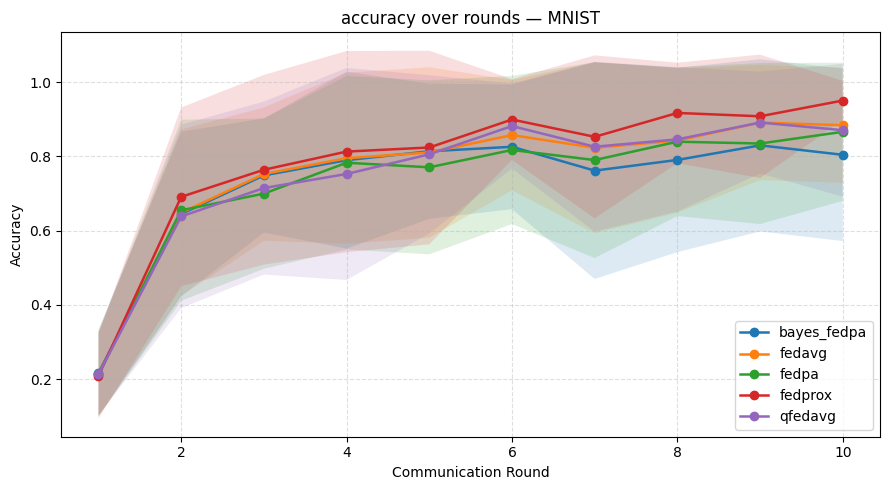

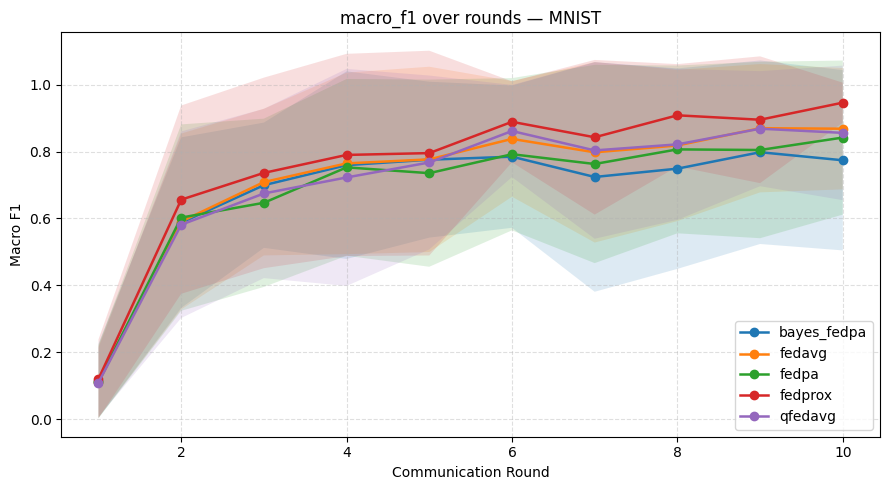

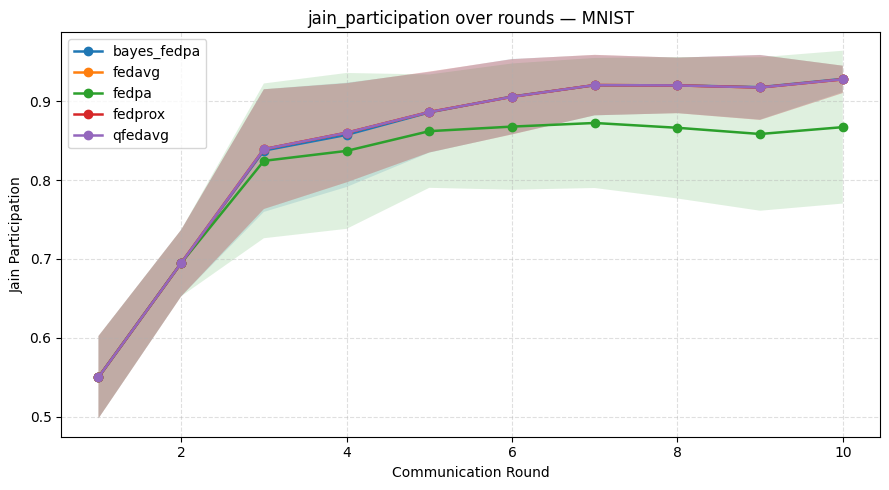

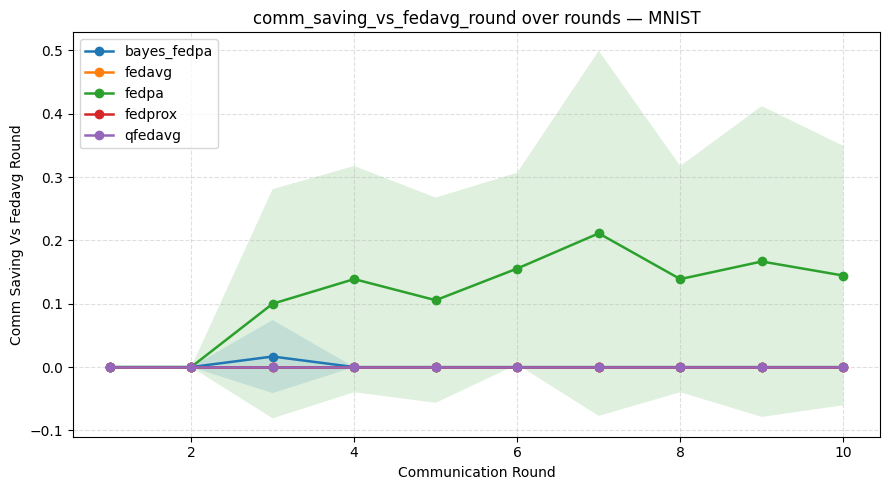

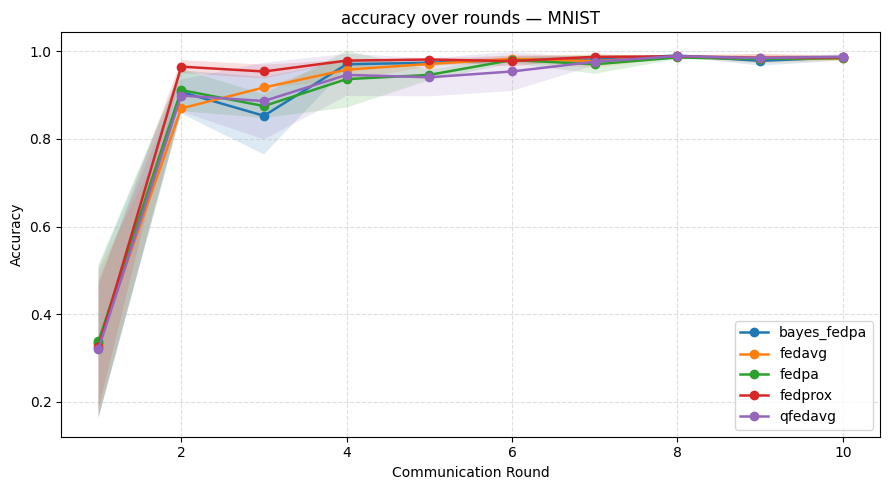

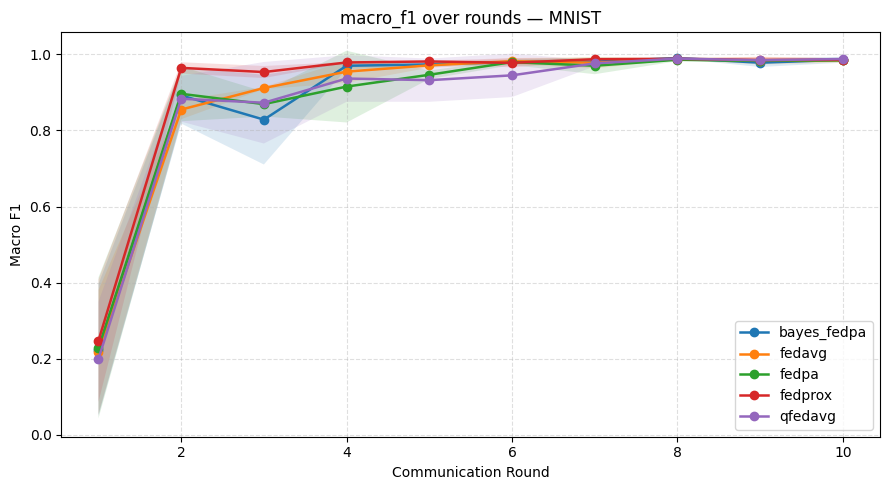

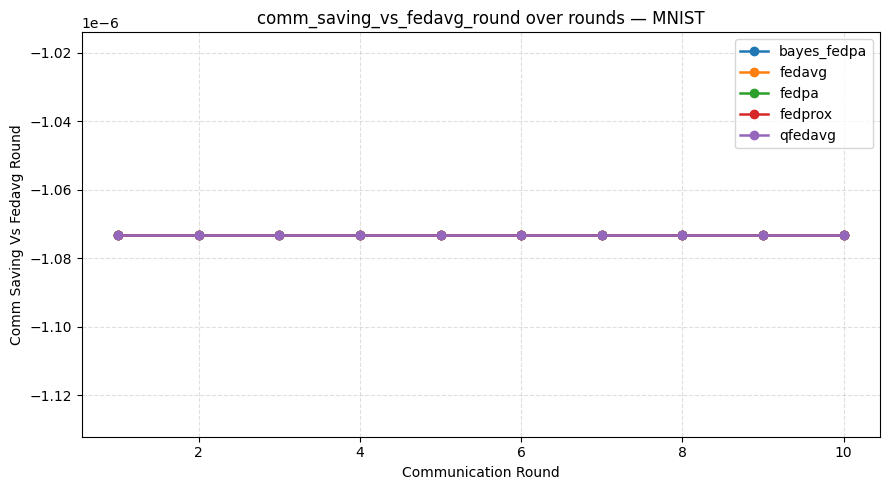

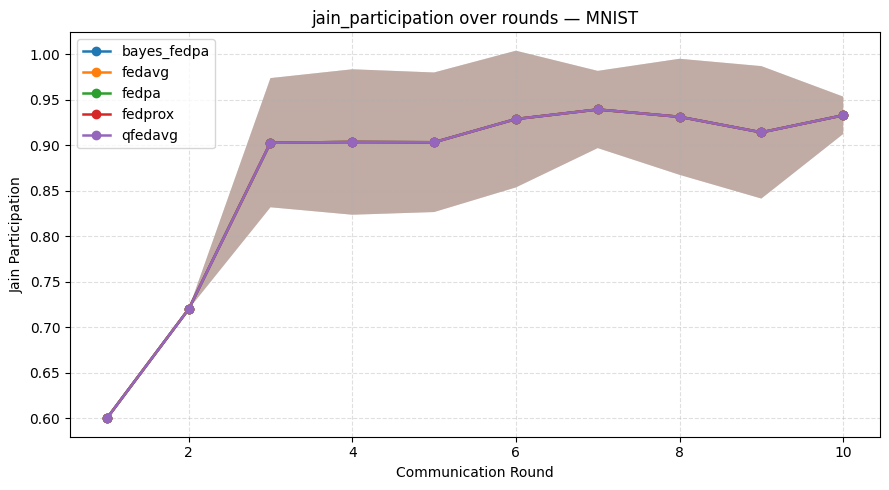

In [ ]:

def plot_metric_over_rounds(df, metric="accuracy", dataset=None, variant="main", title=None, save_name=None):
    if df is None or df.empty:
        print("No data to plot.")
        return
    plot_df = df.copy()
    if dataset is not None:
        plot_df = plot_df[plot_df["dataset"] == dataset]
    if variant is not None:
        plot_df = plot_df[plot_df["variant"] == variant]
    if plot_df.empty:
        print("Filtered data is empty.")
        return

    group_cols = ["method", "round"]
    stats = plot_df.groupby(group_cols)[metric].agg(["mean", "std"]).reset_index()

    plt.figure(figsize=(9, 5))
    for method in stats["method"].unique():
        sub = stats[stats["method"] == method]
        x = sub["round"].values
        y = sub["mean"].values
        s = sub["std"].fillna(0).values
        plt.plot(x, y, marker="o", linewidth=1.8, label=method)
        if len(FULL_SEEDS) > 1:
            plt.fill_between(x, y - s, y + s, alpha=0.15)
    plt.xlabel("Communication Round")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(title or f"{metric} over rounds" + (f" — {dataset}" if dataset else ""))
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    if save_name:
        plt.savefig(OUTPUT_DIR / save_name, dpi=300, bbox_inches="tight")
    plt.show()


def plot_final_bar(summary_df, metric_mean="accuracy_mean", metric_std="accuracy_std", dataset=None, save_name=None):
    if summary_df is None or summary_df.empty:
        print("No summary to plot.")
        return
    plot_df = summary_df.copy()
    if dataset is not None:
        plot_df = plot_df[plot_df["dataset"] == dataset]
    if plot_df.empty:
        print("Filtered summary is empty.")
        return

    labels = [f"{r['method']}\n{r['variant']}" for _, r in plot_df.iterrows()]
    y = plot_df[metric_mean].values
    yerr = plot_df[metric_std].fillna(0).values if metric_std in plot_df.columns else None

    plt.figure(figsize=(max(9, len(labels) * 1.0), 5))
    x = np.arange(len(labels))
    plt.bar(x, y, yerr=yerr, capsize=4)
    plt.xticks(x, labels, rotation=45, ha="right")
    plt.ylabel(metric_mean.replace("_mean", "").replace("_", " ").title())
    plt.title(f"Final {metric_mean.replace('_mean', '')}" + (f" — {dataset}" if dataset else ""))
    plt.grid(True, axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    if save_name:
        plt.savefig(OUTPUT_DIR / save_name, dpi=300, bbox_inches="tight")
    plt.show()

# Main plots per dataset
main_df = core_df[core_df["variant"] == "main"].copy() if "variant" in core_df.columns else core_df.copy()
DATASETS_MAIN = FULL_DATASETS

for ds in DATASETS_MAIN:
    plot_metric_over_rounds(main_df, metric="accuracy", dataset=ds, variant="main", save_name=f"{ds}_main_accuracy_resnet18.png")
    plot_metric_over_rounds(main_df, metric="macro_f1", dataset=ds, variant="main", save_name=f"{ds}_main_macro_f1_resnet18.png")
    plot_metric_over_rounds(main_df, metric="jain_participation", dataset=ds, variant="main", save_name=f"{ds}_main_jain_resnet18.png")
    plot_metric_over_rounds(main_df, metric="comm_saving_vs_fedavg_round", dataset=ds, variant="main", save_name=f"{ds}_main_comm_saving_resnet18.png")


# Example plots. Adjust dataset/alpha/K filters as needed after loading results.
if not core_df.empty:
    for ds in FULL_DATASETS:
        subset = core_df[(core_df["dataset"] == ds) & (core_df["alpha"] == 0.5) & (core_df["num_clients"] == FULL_CLIENT_COUNTS[0])]
        if not subset.empty:
            plot_metric_over_rounds(subset, metric="accuracy", dataset=ds, variant="main", save_name=f"{ds}_accuracy_alpha0p5_K{FULL_CLIENT_COUNTS[0]}.png")
            plot_metric_over_rounds(subset, metric="macro_f1", dataset=ds, variant="main", save_name=f"{ds}_macroF1_alpha0p5_K{FULL_CLIENT_COUNTS[0]}.png")
            plot_metric_over_rounds(subset, metric="comm_saving_vs_fedavg_round", dataset=ds, variant="main", save_name=f"{ds}_commSaving_alpha0p5_K{FULL_CLIENT_COUNTS[0]}.png")
            plot_metric_over_rounds(subset, metric="jain_participation", dataset=ds, variant="main", save_name=f"{ds}_jainFairness_alpha0p5_K{FULL_CLIENT_COUNTS[0]}.png")


## 10. Export Results Package

After experiments and summary generation, this cell creates a ZIP package of CSV summaries, per-run logs, and figures.


In [ ]:

import zipfile
zip_path = OUTPUT_DIR.parent / (OUTPUT_DIR.name + "_MNIST_results.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for file in OUTPUT_DIR.rglob("*"):
        if file.is_file():
            zf.write(file, arcname=str(file.relative_to(OUTPUT_DIR)))
print("Results package created:", zip_path)


Results package created: bayes_fedpa_resnet18_peerj_MNIST_outputs_MNIST_results.zip


## 11. Manuscript-Ready Outputs

Use these files for the revised PeerJ paper:

1. `LEAN_CORE_final_summary_mean_std.csv` — main comparison across datasets, methods, seeds, alphas, and client counts.
2. `LEAN_CORE_all_round_logs.csv` — complete per-round logs from all completed core runs.
3. Dataset partial files such as `MNIST_latest_session_logs.csv`, `ORGANAMNIST_latest_session_logs.csv`, and `OCTMNIST_latest_session_logs.csv`.
4. Accuracy, macro-F1, fairness, and communication plots saved as PNG files.

Recommended manuscript tables:

- Main performance table: accuracy, macro-F1, balanced accuracy, and loss.
- Fairness table: Jain participation, worst-client validation accuracy, and worst-class recall/F1.
- Communication table: selected clients, full uploads, uplink MB, and communication saving versus FedAvg.
- Non-IID sensitivity table: alpha = 0.1, 0.3, 0.5.
- Scalability table: K = 5, 10, 15 clients.

Important note:

This lean setup removes FedAdam, FedYogi, and ablations to make the experiment practical. The retained methods are still scientifically meaningful:
FedAvg, FedProx, q-FedAvg-style, deterministic FedPA, and Bayes-FedPA.


## 12. Later Merge Guidance

After running all three dataset notebooks, collect the three result ZIP files or output folders.

The key files to merge later are:

- `LEAN_CORE_all_round_logs.csv`
- `LEAN_CORE_final_summary_mean_std.csv`

For the final paper table, merge the three `LEAN_CORE_final_summary_mean_std.csv` files.
For plotting all datasets together, merge the three `LEAN_CORE_all_round_logs.csv` files.
